# 01 — Análisis exploratorio de datos (EDA)

**Proyecto:** Prototipo de un sistema de apoyo para la identificación temprana de riesgo de diabetes tipo 2 mediante aprendizaje automático
**Datos:** CDC Diabetes Health Indicators (BRFSS 2015) — archivo completo (desbalanceado) y archivo 50/50.

**Objetivos de este notebook**
1. Describir los datos: estructura, calidad, valores faltantes, duplicados y balance de clases.
2. Explorar distribuciones y correlaciones.
3. Comparar el archivo completo contra el archivo 50/50.
4. Seleccionar los subconjuntos de variables no invasivas y documentar el criterio.
5. Verificar que no exista fuga de información.

## 0. Configuración y carga de datos

In [18]:
# Importar librerías
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Semilla para reproducibilidad (se usa en todas las funciones con random_state)
SEMILLA = 42
np.random.seed(SEMILLA)

# Rutas
ruta = "../data/interim/diabetes_binary_health_indicators_BRFSS2015.csv"
ruta_5050 = "../data/interim/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
ruta_012 = "../data/interim/diabetes_012_health_indicators_BRFSS2015.csv"
dir_figuras = "../reports/figuras"
dir_procesados = "../data/processed"
os.makedirs(dir_figuras, exist_ok=True)
os.makedirs(dir_procesados, exist_ok=True)

# Estilo de gráficas
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

def guardar_figura(nombre):
    # Orden correcto: ajustar -> guardar -> mostrar -> cerrar
    plt.tight_layout()
    plt.savefig(os.path.join(dir_figuras, nombre), dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

# Cargar datos (se conservan los originales y se trabaja sobre copias)
datos_originales = pd.read_csv(ruta)
datos_5050_originales = pd.read_csv(ruta_5050)
datos = datos_originales.copy()
datos_5050 = datos_5050_originales.copy()

variable_objetivo = "Diabetes_binary"
print("Completo:", datos.shape, "| 50/50:", datos_5050.shape)

Completo: (253680, 22) | 50/50: (70692, 22)


## 1. Inspección general

In [19]:
print("Tamaño de los datos (filas, columnas):", datos.shape)
display(datos.head())

# info()
datos.info()

# Estadística descriptiva
display(datos.describe().T)

Tamaño de los datos (filas, columnas): (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


## 2. Calidad de los datos

Se revisan valores faltantes, valores fuera del rango definido en el diccionario de datos de BRFSS,
filas duplicadas y valores extremos del IMC. En esta sección **solo se registra**; las decisiones se
documentan al final de cada bloque.

In [38]:
# 2.1 Valores faltantes
faltantes = datos.isnull().sum()
print("Total de valores faltantes:", int(faltantes.sum()))

# 2.2 Rangos válidos según el diccionario de datos (codebook de BRFSS)
rangos_esperados = {
    "Diabetes_binary": [0, 1], "HighBP": [0, 1], "HighChol": [0, 1], "CholCheck": [0, 1],
    "BMI": (12, 98), "Smoker": [0, 1], "Stroke": [0, 1], "HeartDiseaseorAttack": [0, 1],
    "PhysActivity": [0, 1], "Fruits": [0, 1], "Veggies": [0, 1], "HvyAlcoholConsump": [0, 1],
    "AnyHealthcare": [0, 1], "NoDocbcCost": [0, 1], "GenHlth": (1, 5), "MentHlth": (0, 30),
    "PhysHlth": (0, 30), "DiffWalk": [0, 1], "Sex": [0, 1], "Age": (1, 13),
    "Education": (1, 6), "Income": (1, 8),
}
fuera_de_rango = {}
for col, regla in rangos_esperados.items():
    if isinstance(regla, list):
        fuera_de_rango[col] = int((~datos[col].isin(regla)).sum())
    else:
        fuera_de_rango[col] = int((~datos[col].between(*regla)).sum())
tabla_rangos = pd.DataFrame({
    "min": datos.min(), "max": datos.max(), "valores_unicos": datos.nunique(),
    "fuera_de_rango": pd.Series(fuera_de_rango),
})
display(tabla_rangos)

# 2.3 Todas las columnas son enteras en la práctica (vienen como float); se convierten a int
assert (datos == datos.round()).all().all(), "Hay valores no enteros"
datos = datos.astype(int)
datos_5050 = datos_5050.astype(int)
datos.info()
datos_5050.info()

Total de valores faltantes: 0


,min,max,valores_unicos,fuera_de_rango
Diabetes_binary,0,1,2,0
HighBP,0,1,2,0
HighChol,0,1,2,0
CholCheck,0,1,2,0
BMI,12,98,84,0
Smoker,0,1,2,0
Stroke,0,1,2,0
HeartDiseaseorAttack,0,1,2,0
PhysActivity,0,1,2,0
Fruits,0,1,2,0


<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Diabetes_binary       253680 non-null  int64
 1   HighBP                253680 non-null  int64
 2   HighChol              253680 non-null  int64
 3   CholCheck             253680 non-null  int64
 4   BMI                   253680 non-null  int64
 5   Smoker                253680 non-null  int64
 6   Stroke                253680 non-null  int64
 7   HeartDiseaseorAttack  253680 non-null  int64
 8   PhysActivity          253680 non-null  int64
 9   Fruits                253680 non-null  int64
 10  Veggies               253680 non-null  int64
 11  HvyAlcoholConsump     253680 non-null  int64
 12  AnyHealthcare         253680 non-null  int64
 13  NoDocbcCost           253680 non-null  int64
 14  GenHlth               253680 non-null  int64
 15  MentHlth              253680 non-null  int64


In [21]:
# 2.4 Filas duplicadas
n_dup = datos.duplicated().sum()
print(f"Filas duplicadas: {n_dup} ({n_dup / len(datos):.1%})")

# ¿Qué efecto tendría eliminarlas?
prev_original = datos[variable_objetivo].mean()
prev_sin_dup = datos.drop_duplicates()[variable_objetivo].mean()
print(f"Prevalencia de diabetes con duplicados: {prev_original:.2%}")
print(f"Prevalencia de diabetes sin duplicados: {prev_sin_dup:.2%}")

# ¿Qué perfil tienen las filas duplicadas comparado con el total?
perfil = pd.DataFrame({
    "media_duplicados": datos[datos.duplicated(keep=False)].mean(),
    "media_total": datos.mean(),
}).round(2)
display(perfil)

Filas duplicadas: 24206 (9.5%)
Prevalencia de diabetes con duplicados: 13.93%
Prevalencia de diabetes sin duplicados: 15.29%


,media_duplicados,media_total
Diabetes_binary,0.01,0.14
HighBP,0.21,0.43
HighChol,0.28,0.42
CholCheck,0.99,0.96
BMI,25.68,28.38
Smoker,0.25,0.44
Stroke,0.00,0.04
HeartDiseaseorAttack,0.01,0.09
PhysActivity,0.97,0.76
Fruits,0.82,0.63


**Decisión sobre duplicados: se conservan.**

- Casi todas las variables son binarias o de pocas categorías, por lo que es esperable que personas
  distintas den respuestas idénticas.
- La tabla anterior muestra que los duplicados corresponden a un perfil sano (baja presión alta, IMC
  bajo, buena salud general, alta actividad física). Son respuestas plausibles, no errores de captura.
- Eliminarlos cambiaría la prevalencia de diabetes (de 13.9% a 15.3%) y quitaría precisamente los
  perfiles de menor riesgo, lo que sesgaría los datos.
- En la sección 9 se verifica que conservarlos **no infla** el desempeño del modelo.

In [22]:
# 2.5 Valores extremos del IMC
for limite in [50, 60, 80]:
    print(f"IMC > {limite}: {(datos['BMI'] > limite).sum()} registros")
print("Percentiles 1 y 99 del IMC:", datos["BMI"].quantile([0.01, 0.99]).to_list())

IMC > 50: 2175 registros
IMC > 60: 805 registros
IMC > 80: 279 registros
Percentiles 1 y 99 del IMC: [18.0, 50.0]


**Decisión sobre el IMC:** los valores extremos se conservan en el EDA. Su tratamiento (por ejemplo,
recortar al percentil 99) se decide en el notebook de preprocesamiento, aplicando la regla solo con
los datos de entrenamiento.

## 3. Definición de la variable objetivo

Antes de analizar, es necesario saber **qué significa exactamente** `Diabetes_binary = 1`.

En el archivo completo hay 218,334 negativos y 35,346 positivos. El archivo de tres clases
(`diabetes_012`) reporta 213,703 sin diabetes, 4,631 con prediabetes y 35,346 con diabetes, y
213,703 + 4,631 = 218,334. Esto indica que, **en este archivo, la prediabetes quedó codificada como 0**
(junto con "sin diabetes"). La celda siguiente lo confirma si tienes el archivo `diabetes_012` en la
misma carpeta (viene en la misma descarga de Kaggle).

Implicaciones que deben documentarse en la tesis:
- La etiqueta es **diabetes diagnosticada y autorreportada** ("¿algún médico le ha dicho que tiene diabetes?").
- No distingue entre diabetes tipo 1 y tipo 2.

In [23]:
if os.path.exists(ruta_012):
    datos_012 = pd.read_csv(ruta_012).astype(int)
    print(datos_012["Diabetes_012"].value_counts().sort_index())
    # Si las filas están alineadas, la tabla cruzada muestra cómo se recodificó cada clase
    if len(datos_012) == len(datos):
        display(pd.crosstab(datos_012["Diabetes_012"], datos[variable_objetivo]))
else:
    print("No se encontró el archivo diabetes_012; la verificación queda pendiente.")

Diabetes_012
0    213703
1      4631
2     35346
Name: count, dtype: int64


Diabetes_binary,0,1
Diabetes_012,,
0,213703,0
1,4631,0
2,0,35346


## 4. Balance de clases y partición entrenamiento / prueba

,Completo (n),Completo (%),50/50 (n),50/50 (%)
Sin diabetes (0),218334,86.07,35346,50.0
Con diabetes (1),35346,13.93,35346,50.0


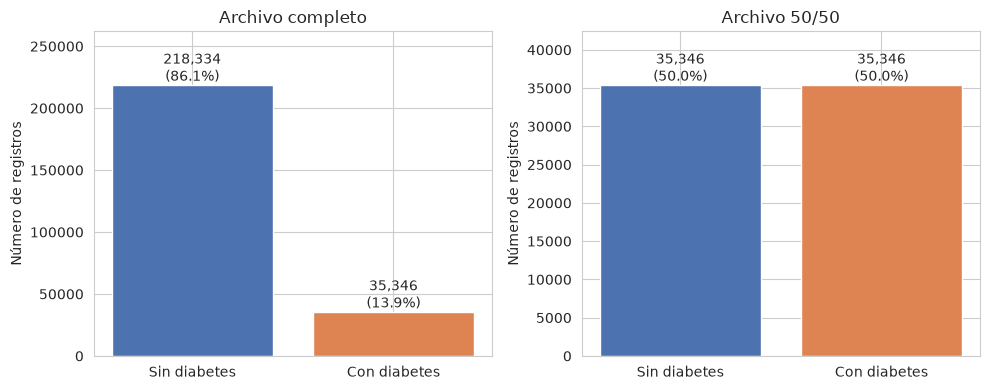

In [24]:
# 4.1 Balance de clases en ambos archivos
balance = pd.DataFrame({
    "Completo (n)": datos[variable_objetivo].value_counts(),
    "Completo (%)": datos[variable_objetivo].value_counts(normalize=True).mul(100).round(2),
    "50/50 (n)": datos_5050[variable_objetivo].value_counts(),
    "50/50 (%)": datos_5050[variable_objetivo].value_counts(normalize=True).mul(100).round(2),
})
balance.index = ["Sin diabetes (0)", "Con diabetes (1)"]
display(balance)

fig, ejes = plt.subplots(1, 2, figsize=(10, 4))
for eje, (nombre, df) in zip(ejes, [("Archivo completo", datos), ("Archivo 50/50", datos_5050)]):
    conteo = df[variable_objetivo].value_counts().sort_index()
    eje.bar(["Sin diabetes", "Con diabetes"], conteo.values, color=["#4c72b0", "#dd8452"])
    for i, v in enumerate(conteo.values):
        eje.text(i, v, f"{v:,}\n({v / conteo.sum():.1%})", ha="center", va="bottom")
    eje.set_title(nombre); eje.set_ylabel("Número de registros")
    eje.set_ylim(0, conteo.max() * 1.2)
guardar_figura("01_balance_clases.png")

In [25]:
# 4.2 Partición estratificada 80/20 sobre el archivo completo (con duplicados, ver sección 2)
X = datos.drop(columns=[variable_objetivo])
y = datos[variable_objetivo]

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X, y,
    test_size=0.20,      # 20% para prueba
    random_state=SEMILLA,
    stratify=y,          # mantiene la proporción de clases en ambos conjuntos
)

entrenamiento = X_entrenamiento.copy()
entrenamiento[variable_objetivo] = y_entrenamiento

print("Entrenamiento:", X_entrenamiento.shape, "| Prueba:", X_prueba.shape)
print("Prevalencia entrenamiento:", round(y_entrenamiento.mean(), 4))
print("Prevalencia prueba:       ", round(y_prueba.mean(), 4))
# A partir de aquí, el EDA usa SOLO 'entrenamiento'.

Entrenamiento: (202944, 21) | Prueba: (50736, 21)
Prevalencia entrenamiento: 0.1393
Prevalencia prueba:        0.1393


## 5. Distribuciones (solo entrenamiento)

Las variables se clasifican explícitamente según el diccionario de datos (en lugar de usar el número de
valores únicos):

- **Numéricas:** IMC y días de mala salud mental o física.
- **Ordinales:** salud general, edad, educación e ingreso.
- **Binarias:** el resto.

Como las clases están desbalanceadas, los histogramas apilados y los conteos ocultan a la clase
positiva. Por eso se usan **densidades por clase** (cada clase normalizada por separado) y la **tasa de
diabetes por categoría**, con la prevalencia general como línea de referencia.

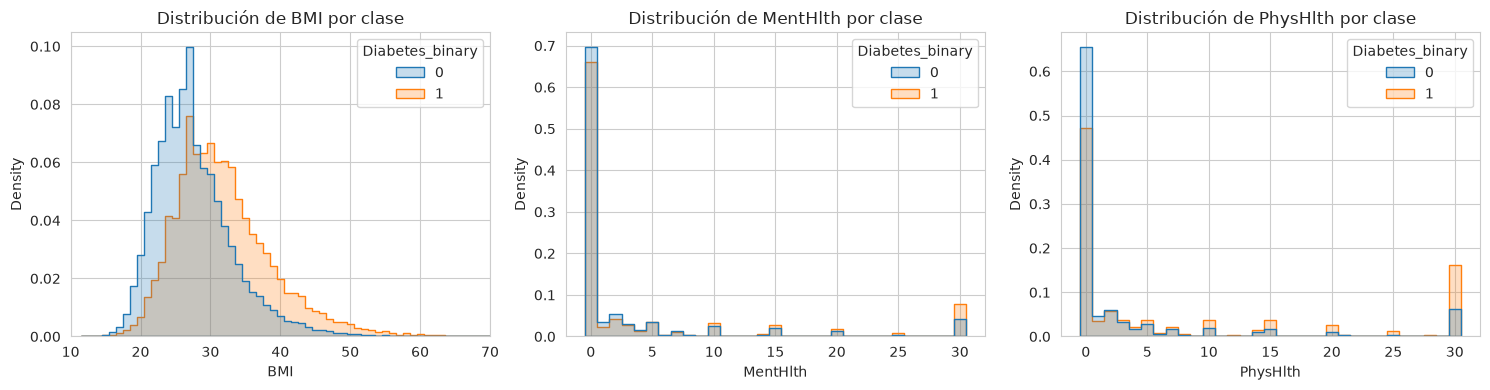

Diabetes_binary         0        1
BMI      count   174667.0  28277.0
         mean        27.8     32.0
         std          6.3      7.4
         min         12.0     13.0
         25%         24.0     27.0
         50%         27.0     31.0
         75%         31.0     36.0
         max         98.0     98.0
MentHlth count   174667.0  28277.0
         mean         3.0      4.5
         std          7.1      9.0
         min          0.0      0.0
         25%          0.0      0.0
         50%          0.0      0.0
         75%          2.0      3.0
         max         30.0     30.0
PhysHlth count   174667.0  28277.0
         mean         3.6      8.0
         std          8.1     11.3
         min          0.0      0.0
         25%          0.0      0.0
         50%          0.0      1.0
         75%          2.0     15.0
         max         30.0     30.0

In [26]:
cols_numericas = ["BMI", "MentHlth", "PhysHlth"]
cols_ordinales = ["GenHlth", "Age", "Education", "Income"]
cols_binarias = [c for c in X.columns if c not in cols_numericas + cols_ordinales]
prevalencia = entrenamiento[variable_objetivo].mean()

# 5.1 Variables numéricas: densidad por clase
fig, ejes = plt.subplots(1, 3, figsize=(15, 4))
for eje, col in zip(ejes, cols_numericas):
    sns.histplot(data=entrenamiento, x=col, hue=variable_objetivo, stat="density",
                 common_norm=False, discrete=True,
                 element="step", ax=eje)
    eje.set_title(f"Distribución de {col} por clase")
    if col == "BMI":
        eje.set_xlim(10, 70)
guardar_figura("02_numericas_por_clase.png")

display(entrenamiento.groupby(variable_objetivo)[cols_numericas].describe().T.round(1))

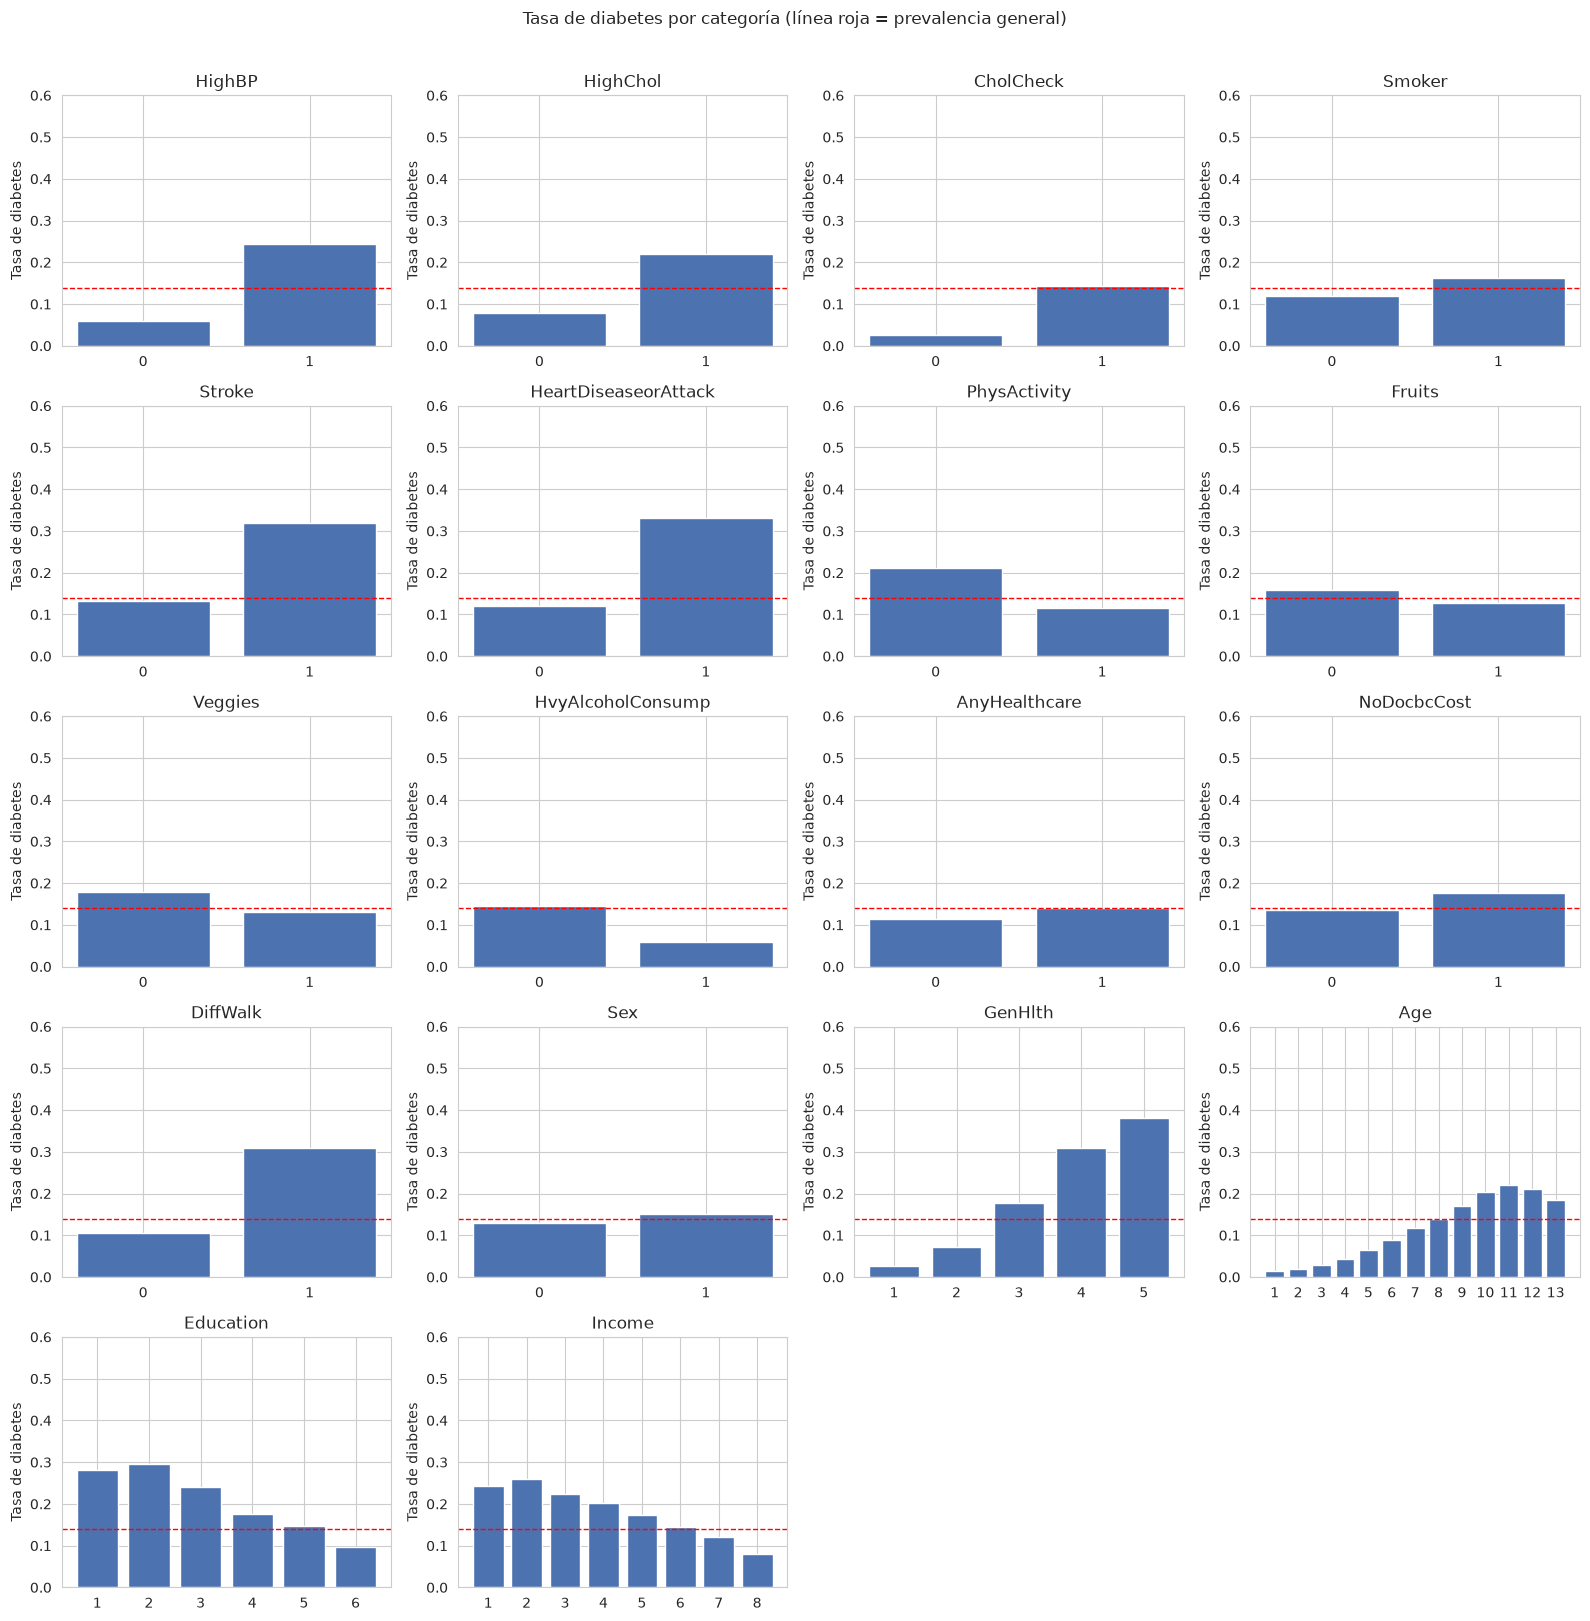

In [27]:
# 5.2 Tasa de diabetes por categoría (binarias y ordinales)
cols_categoricas = cols_binarias + cols_ordinales
n_cols = 4
n_filas = int(np.ceil(len(cols_categoricas) / n_cols))
fig, ejes = plt.subplots(n_filas, n_cols, figsize=(16, 3.2 * n_filas))
for eje, col in zip(ejes.flat, cols_categoricas):
    tasa = entrenamiento.groupby(col)[variable_objetivo].mean()
    eje.bar(tasa.index.astype(str), tasa.values, color="#4c72b0")
    eje.axhline(prevalencia, color="red", linestyle="--", linewidth=1)
    eje.set_title(col); eje.set_ylabel("Tasa de diabetes"); eje.set_ylim(0, 0.6)
for eje in list(ejes.flat)[len(cols_categoricas):]:
    eje.axis("off")
fig.suptitle("Tasa de diabetes por categoría (línea roja = prevalencia general)", y=1.01)
guardar_figura("03_tasa_diabetes_por_categoria.png")

# Tabla de apoyo (tasa y número de registros por categoría) para anexos
tabla_tasas = pd.concat({
    col: entrenamiento.groupby(col)[variable_objetivo].agg(tasa="mean", n="size")
    for col in cols_categoricas
}).round(3)
tabla_tasas.to_csv(os.path.join(dir_figuras, "tabla_tasas_por_categoria.csv"))

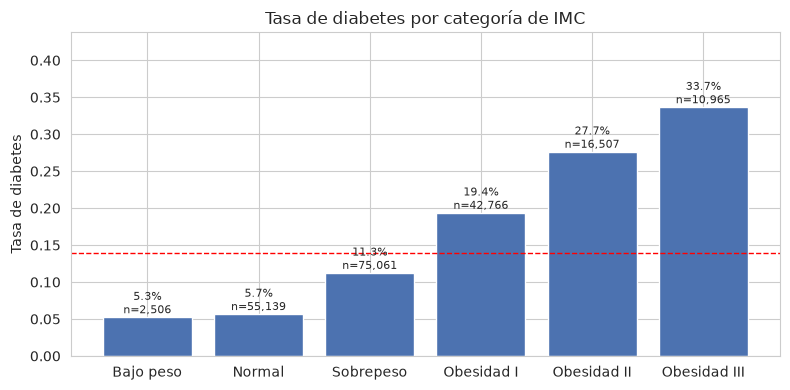

In [28]:
# 5.3 Tasa de diabetes por categoría de IMC (clasificación de la OMS)
cortes = [0, 18.5, 25, 30, 35, 40, 100]
etiquetas = ["Bajo peso", "Normal", "Sobrepeso", "Obesidad I", "Obesidad II", "Obesidad III"]
categoria_imc = pd.cut(entrenamiento["BMI"], bins=cortes, labels=etiquetas, right=False)
tasa_imc = entrenamiento.groupby(categoria_imc, observed=True)[variable_objetivo].agg(["mean", "size"])

plt.figure(figsize=(8, 4))
plt.bar(tasa_imc.index.astype(str), tasa_imc["mean"], color="#4c72b0")
plt.axhline(prevalencia, color="red", linestyle="--", linewidth=1)
for i, (t, n) in enumerate(zip(tasa_imc["mean"], tasa_imc["size"])):
    plt.text(i, t, f"{t:.1%}\nn={n:,}", ha="center", va="bottom", fontsize=8)
plt.ylabel("Tasa de diabetes"); plt.ylim(0, tasa_imc["mean"].max() * 1.3)
plt.title("Tasa de diabetes por categoría de IMC")
guardar_figura("04_tasa_diabetes_por_imc.png")

**📝 Hallazgos de la sección 5 (escríbelos tú, con tus palabras):**
- ¿Qué variables muestran una tasa de diabetes claramente distinta entre sus categorías?
  
  Las variables HighBP, GenHlth, Age y BMI presentan las mayores diferencias en la tasa de diabetes entre sus categorías; en HighBP, la tasa en personas con presión alta es aproximadamente cuatro veces mayor que en quienes no la tienen.

- ¿La relación con la edad y con el IMC es creciente, como se esperaría?
  
  La respuesta es sí, es creciente como se esperaria en ambos casos con alguna excepcion en la edad al final qdonde la tasa comienxa a disminuir entre el 12 y el 13 que tiene que ver conla edad avanzada de las personas y menor numero de poblacion.

- ¿Qué observas en MentHlth y PhysHlth (concentración en 0 y en 30)?
  
  Hay una mayor conentracion en 0 en ambas y un pequeño grupo en 30 con algunos picos en entre medias, pero no se tomaran en cuenta por que pueden ser una consecuencia de la diabetes y no una causa como tal.

- ¿Hay categorías con muy pocos registros que convenga agrupar?
  Segun las tasa por categorias muetra que no hay que agrupar categorias, la mayoria de las categorias sobre pasa los registro.

## 6. Correlaciones (Spearman, solo entrenamiento)

Se usa Spearman porque la mayoría de las variables son binarias u ordinales. La matriz se ordena por la
correlación con la variable objetivo. Además se listan los pares de predictores muy correlacionados
entre sí (posible redundancia).

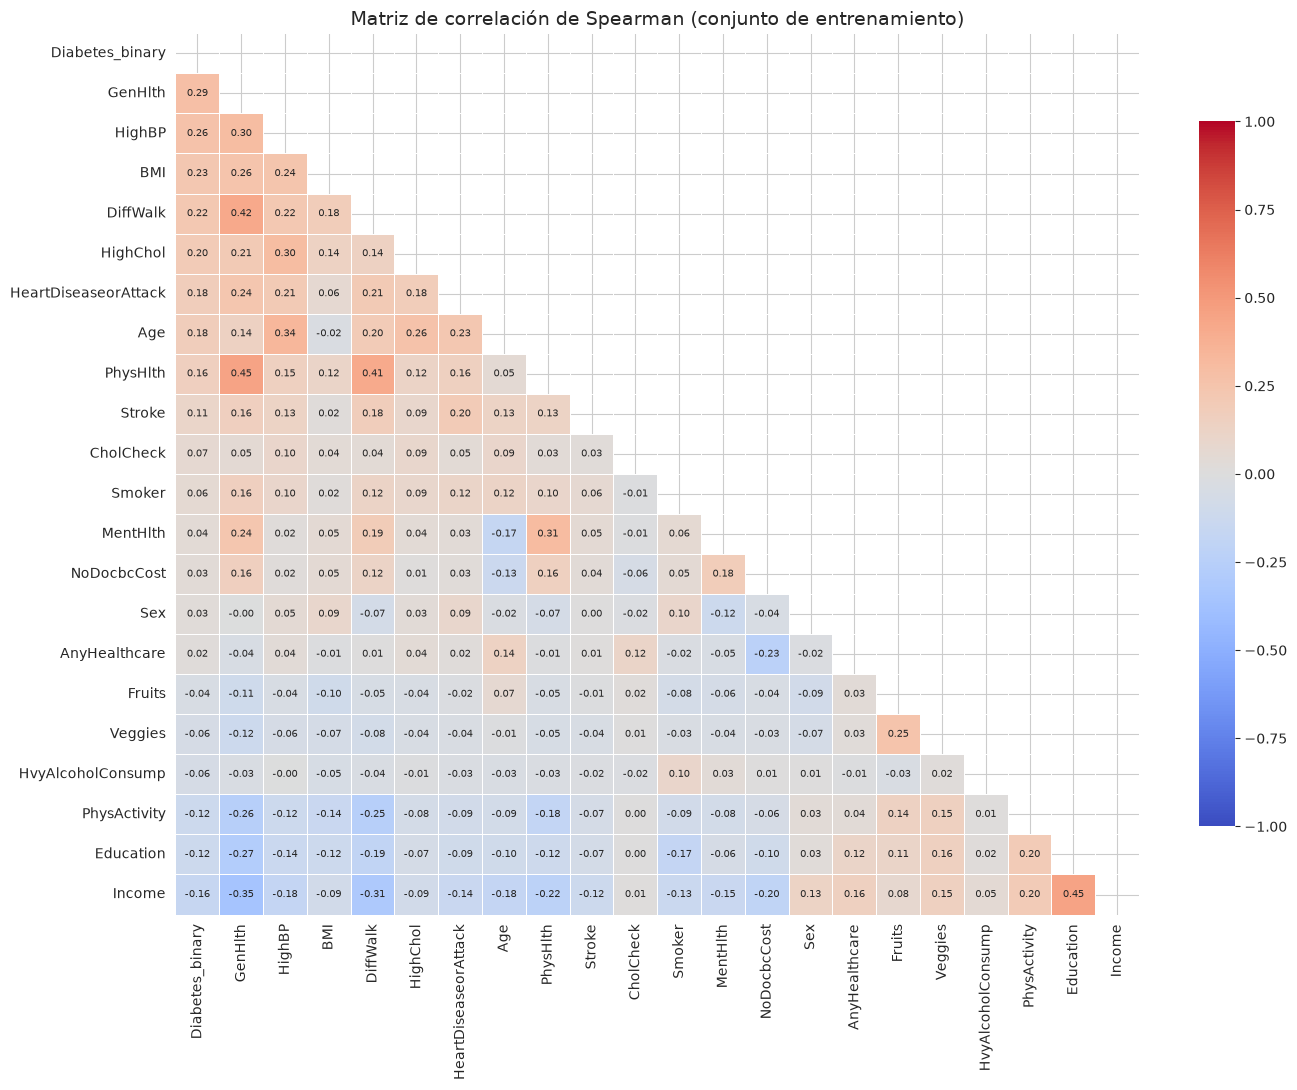

In [29]:
corr_spearman = entrenamiento.corr(method="spearman")
orden_corr = corr_spearman[variable_objetivo].sort_values(ascending=False).index
corr_ordenada = corr_spearman.loc[orden_corr, orden_corr]

plt.figure(figsize=(14, 11))
mascara = np.triu(np.ones_like(corr_ordenada, dtype=bool))
sns.heatmap(corr_ordenada, mask=mascara, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={"size": 7}, cbar_kws={"shrink": .8})
plt.title("Matriz de correlación de Spearman (conjunto de entrenamiento)", fontsize=14)
guardar_figura("05_matriz_correlacion_spearman.png")

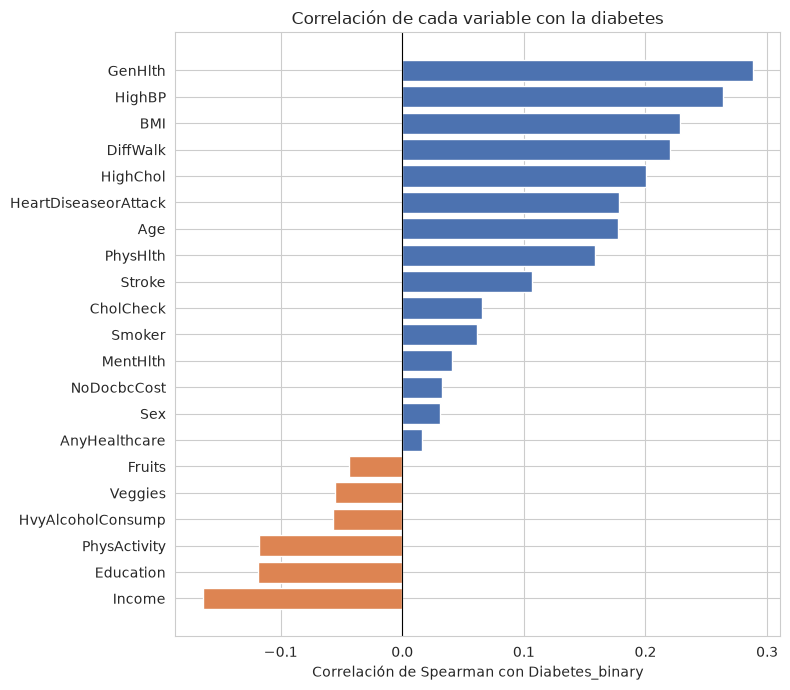

,level_0,level_1,rho
419,Education,Income,0.452142
288,GenHlth,PhysHlth,0.452059
289,GenHlth,DiffWalk,0.421780
331,PhysHlth,DiffWalk,0.413911


In [30]:
# Correlación de cada variable con la variable objetivo
corr_objetivo = corr_spearman[variable_objetivo].drop(variable_objetivo).sort_values()
plt.figure(figsize=(8, 7))
plt.barh(corr_objetivo.index, corr_objetivo.values,
         color=["#dd8452" if v < 0 else "#4c72b0" for v in corr_objetivo.values])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Correlación de Spearman con Diabetes_binary")
plt.title("Correlación de cada variable con la diabetes")
guardar_figura("06_correlacion_con_objetivo.png")

# Pares de predictores con |rho| >= 0.4
pares = (corr_spearman.drop(index=variable_objetivo, columns=variable_objetivo)
         .where(np.triu(np.ones((len(X.columns), len(X.columns)), dtype=bool), k=1))
         .stack().rename("rho").reset_index())
display(pares[pares["rho"].abs() >= 0.4].sort_values("rho", key=abs, ascending=False))

**📝 Hallazgos de la sección 6 (escríbelos tú):**
- ¿Cuáles son las 5 variables más correlacionadas con la diabetes? ¿Son esperables clínicamente?
  
  GenHlth,HighBP,BMI,DiffWalk,HighChol
  Si son esperables, por que tiene que ver mayormente con cuestiones de la movilidad y de salud general.
- ¿Qué grupos de predictores están muy relacionados entre sí (por ejemplo, GenHlth, PhysHlth y DiffWalk)?
  
  Ninguna correlación entre predictores pasa de 0.45. Los umbrales habituales de colinealidad preocupante están en 0.7 u 0.8, así que no hay redundancia grave. 
  Las variables que más se parecen entre sí (GenHlth, PhysHlth, DiffWalk, Education e Income) son justo las que quedaron fuera de tu conjunto final. Entre las 7 que conservaste, la relación más alta es Age–HighBP (0.34), así que tu conjunto no tiene problemas de colinealidad.

- Recuerda: con más de 200 mil registros casi cualquier correlación es "significativa"; importa la magnitud.

## 7. Comparación: archivo completo vs archivo 50/50

> **Nota para la tesis:** esta comparación sustituye a la comparación con Ensanut, pero **no responde la
> misma pregunta**. Comparar con Ensanut indicaría qué tan distinta es la población mexicana; comparar con
> el archivo 50/50 indica **qué efecto tiene el balanceo**. Si se elimina Ensanut, la limitación de
> "población estadounidense" debe declararse explícitamente (o contrastarse con cifras publicadas de Ensanut).

Preguntas que responde esta sección:
1. ¿El archivo 50/50 está contenido en el completo?
2. ¿Sus distribuciones dentro de cada clase son iguales (submuestreo fiel)?
3. ¿Cómo cambian las distribuciones generales al balancear?

In [31]:
# 7.1 ¿Las filas del 50/50 están en el completo?
completo_unico = datos.drop_duplicates()
presentes = datos_5050.merge(completo_unico, how="left", indicator=True)["_merge"].eq("both").mean()
print(f"Filas del 50/50 presentes en el completo: {presentes:.1%}")

# ¿Los positivos son exactamente los mismos registros (como multiconjunto)?
pos_completo = datos[datos[variable_objetivo] == 1].value_counts().sort_index()
pos_5050 = datos_5050[datos_5050[variable_objetivo] == 1].value_counts().sort_index()
print("Positivos idénticos en ambos archivos:", pos_completo.equals(pos_5050))

Filas del 50/50 presentes en el completo: 100.0%
Positivos idénticos en ambos archivos: True


,media_completo,media_5050,SMD_general,SMD_clase_0
GenHlth,2.511,2.837,0.298,-0.002
HighBP,0.429,0.563,0.271,-0.005
BMI,28.382,29.857,0.215,-0.006
DiffWalk,0.168,0.253,0.208,-0.003
HighChol,0.424,0.526,0.204,-0.006
Age,8.032,8.584,0.187,-0.008
PhysHlth,4.242,5.810,0.167,0.003
Income,6.054,5.698,-0.167,-0.002
HeartDiseaseorAttack,0.094,0.148,0.165,-0.002
Education,5.050,4.921,-0.128,-0.004


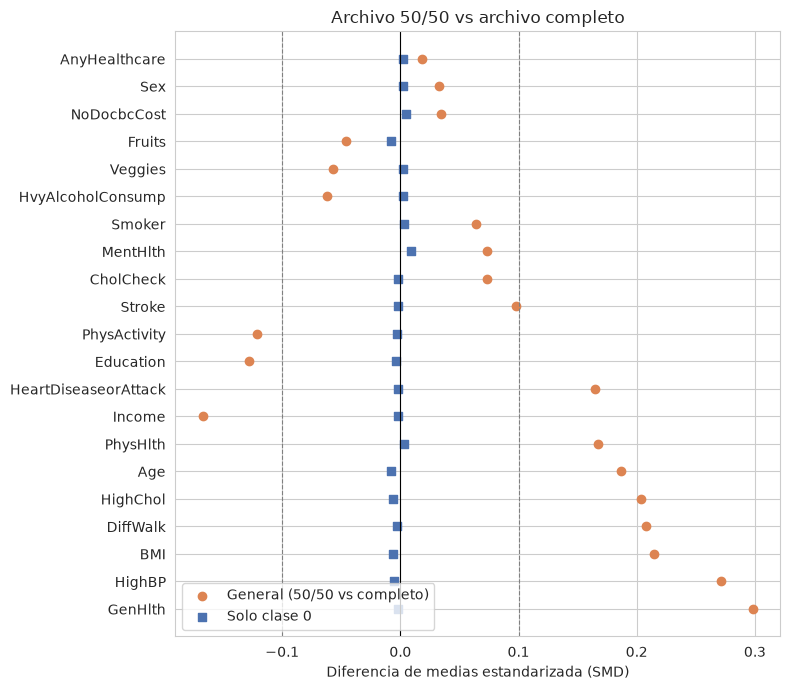

In [32]:
# 7.2 Diferencia de medias estandarizada (SMD). Regla usual: |SMD| < 0.1 = diferencia despreciable
def smd(a, b):
    return (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)

comparacion = pd.DataFrame({
    "media_completo": datos[X.columns].mean(),
    "media_5050": datos_5050[X.columns].mean(),
    "SMD_general": smd(datos_5050[X.columns], datos[X.columns]),
    "SMD_clase_0": smd(datos_5050.loc[datos_5050[variable_objetivo] == 0, X.columns],
                       datos.loc[datos[variable_objetivo] == 0, X.columns]),
}).round(3).sort_values("SMD_general", key=abs, ascending=False)
display(comparacion)

plt.figure(figsize=(8, 7))
pos = np.arange(len(comparacion))
plt.scatter(comparacion["SMD_general"], pos, label="General (50/50 vs completo)", color="#dd8452")
plt.scatter(comparacion["SMD_clase_0"], pos, label="Solo clase 0", color="#4c72b0", marker="s")
plt.yticks(pos, comparacion.index)
for x in (-0.1, 0.1):
    plt.axvline(x, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Diferencia de medias estandarizada (SMD)")
plt.title("Archivo 50/50 vs archivo completo")
plt.legend(loc="lower left")
guardar_figura("07_comparacion_completo_vs_5050.png")

**Interpretación esperada (verifícala con tus resultados):**
- El 50/50 está formado por **todos** los positivos del archivo completo más una muestra aleatoria de
  negativos. Dentro de la clase 0 las diferencias son despreciables (submuestreo fiel).
- Las diferencias generales aparecen porque el 50/50 tiene muchos más positivos: las variables asociadas a
  diabetes (presión alta, salud general, edad, IMC) se ven "más frecuentes" que en la población real.

**Consecuencias para el modelado:**
- El conjunto de prueba debe venir del archivo completo (prevalencia real).
- **No se debe entrenar con el 50/50 y probar con el completo:** todos los positivos de la prueba ya
  estarían en el entrenamiento (ver sección 9.4).
- Si se requiere balancear, se hace **solo dentro del conjunto de entrenamiento** (pesos de clase o submuestreo).

## 8. Selección de variables no invasivas

**Criterios** (una variable entra al conjunto estricto solo si cumple los cuatro):
1. La persona puede responderla al usar la herramienta, sin laboratorio ni medición clínica.
2. Se conoce antes del desenlace y no es consecuencia del diagnóstico (sin causalidad inversa).
3. No es un criterio diagnóstico ni un sustituto (*proxy*) de contacto con el sistema de salud.
4. Puede preguntarse en el formulario del prototipo.

Se definen tres conjuntos para un **análisis de sensibilidad** en el modelado:
- **Estricto:** cumple los cuatro criterios.
- **Ampliado:** agrega variables autorreportables con riesgo de causalidad inversa y la presión alta,
  que la persona suele conocer y que también considera FINDRISC.
- **Completo:** las 21 variables, como referencia.

In [33]:
filas = [
    # variable, grupo, descripción, sin_laboratorio, riesgo_causalidad_inversa, conjunto, justificación
    ("Age", "Demográfica", "Grupo de edad (13 categorías de 5 años)", "Sí", "No", "Estricto", "Dato que la persona conoce"),
    ("Sex", "Demográfica", "Sexo", "Sí", "No", "Estricto", "Dato que la persona conoce"),
    ("Education", "Demográfica", "Nivel educativo (1-6)", "Sí", "No", "Estricto", "Determinante social; autorreportable"),
    ("Income", "Demográfica", "Nivel de ingreso (1-8)", "Sí", "No", "Estricto", "Determinante social; autorreportable"),
    ("BMI", "Antropométrica", "Índice de masa corporal", "Sí", "No", "Estricto", "Se calcula con peso y estatura"),
    ("Smoker", "Estilo de vida", "Ha fumado al menos 100 cigarrillos", "Sí", "No", "Estricto", "Autorreportable"),
    ("PhysActivity", "Estilo de vida", "Actividad física en los últimos 30 días", "Sí", "Bajo", "Estricto", "Autorreportable; también en FINDRISC"),
    ("Fruits", "Estilo de vida", "Consume fruta al menos una vez al día", "Sí", "Bajo", "Estricto", "Autorreportable; también en FINDRISC"),
    ("Veggies", "Estilo de vida", "Consume verduras al menos una vez al día", "Sí", "Bajo", "Estricto", "Autorreportable; también en FINDRISC"),
    ("HvyAlcoholConsump", "Estilo de vida", "Consumo excesivo de alcohol", "Sí", "No", "Estricto", "Autorreportable"),
    ("GenHlth", "Percepción de salud", "Salud general percibida (1-5)", "Sí", "Alto", "Ampliado", "Puede empeorar a consecuencia de la diabetes"),
    ("MentHlth", "Percepción de salud", "Días de mala salud mental (0-30)", "Sí", "Medio", "Ampliado", "Puede ser consecuencia de la enfermedad"),
    ("PhysHlth", "Percepción de salud", "Días de mala salud física (0-30)", "Sí", "Alto", "Ampliado", "Puede ser consecuencia de la enfermedad"),
    ("DiffWalk", "Percepción de salud", "Dificultad para caminar", "Sí", "Alto", "Ampliado", "Puede ser complicación (neuropatía, obesidad)"),
    ("HighBP", "Diagnóstico previo", "Le han dicho que tiene presión alta", "Sí, si la conoce", "Medio", "Ampliado", "Requiere diagnóstico previo; FINDRISC pregunta por antihipertensivos"),
    ("HighChol", "Diagnóstico previo", "Le han dicho que tiene colesterol alto", "No", "Medio", "Completo", "Requiere análisis de sangre"),
    ("Stroke", "Diagnóstico previo", "Ha tenido un infarto cerebral", "Sí", "Alto", "Completo", "Posible complicación de la diabetes"),
    ("HeartDiseaseorAttack", "Diagnóstico previo", "Enfermedad coronaria o infarto", "Sí", "Alto", "Completo", "Posible complicación de la diabetes"),
    ("CholCheck", "Acceso a salud", "Revisión de colesterol en 5 años", "Sí", "Alto", "Completo", "Proxy de contacto con el sistema de salud"),
    ("AnyHealthcare", "Acceso a salud", "Tiene cobertura de salud", "Sí", "Medio", "Completo", "Proxy de contacto con el sistema de salud"),
    ("NoDocbcCost", "Acceso a salud", "No fue al médico por costo", "Sí", "Medio", "Completo", "Proxy de acceso a salud"),
]
tabla_variables = pd.DataFrame(filas, columns=[
    "variable", "grupo", "descripcion", "obtenible_sin_laboratorio",
    "riesgo_causalidad_inversa", "conjunto_minimo", "justificacion"])
display(tabla_variables)
tabla_variables.to_csv(os.path.join(dir_figuras, "tabla_seleccion_variables.csv"), index=False)

orden = {"Estricto": 1, "Ampliado": 2, "Completo": 3}
nivel = tabla_variables.set_index("variable")["conjunto_minimo"].map(orden)
conjuntos = {
    "estricto": nivel[nivel <= 1].index.tolist(),
    "ampliado": nivel[nivel <= 2].index.tolist(),
    "completo": nivel[nivel <= 3].index.tolist(),
}
assert set(conjuntos["completo"]) == set(X.columns), "La tabla no cubre todas las variables"
for nombre, cols in conjuntos.items():
    print(f"{nombre:<9}: {len(cols)} variables -> {cols}")

,variable,grupo,descripcion,obtenible_sin_laboratorio,riesgo_causalidad_inversa,conjunto_minimo,justificacion
0,Age,Demográfica,Grupo de edad (13 categorías de 5 años),Sí,No,Estricto,Dato que la persona conoce
1,Sex,Demográfica,Sexo,Sí,No,Estricto,Dato que la persona conoce
2,Education,Demográfica,Nivel educativo (1-6),Sí,No,Estricto,Determinante social; autorreportable
3,Income,Demográfica,Nivel de ingreso (1-8),Sí,No,Estricto,Determinante social; autorreportable
4,BMI,Antropométrica,Índice de masa corporal,Sí,No,Estricto,Se calcula con peso y estatura
5,Smoker,Estilo de vida,Ha fumado al menos 100 cigarrillos,Sí,No,Estricto,Autorreportable
6,PhysActivity,Estilo de vida,Actividad física en los últimos 30 días,Sí,Bajo,Estricto,Autorreportable; también en FINDRISC
7,Fruits,Estilo de vida,Consume fruta al menos una vez al día,Sí,Bajo,Estricto,Autorreportable; también en FINDRISC
8,Veggies,Estilo de vida,Consume verduras al menos una vez al día,Sí,Bajo,Estricto,Autorreportable; también en FINDRISC
9,HvyAlcoholConsump,Estilo de vida,Consumo excesivo de alcohol,Sí,No,Estricto,Autorreportable


estricto : 10 variables -> ['Age', 'Sex', 'Education', 'Income', 'BMI', 'Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump']
ampliado : 15 variables -> ['Age', 'Sex', 'Education', 'Income', 'BMI', 'Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'HighBP']
completo : 21 variables -> ['Age', 'Sex', 'Education', 'Income', 'BMI', 'Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack', 'CholCheck', 'AnyHealthcare', 'NoDocbcCost']


**Nota sobre FINDRISC:** el conjunto estricto solo cubre parte del cuestionario (edad, IMC, actividad
física, frutas y verduras; presión alta en el ampliado). Faltan perímetro de cintura, antecedente de
glucosa elevada y antecedentes familiares. Por ello, cualquier comparación con FINDRISC en este dataset
será una **aproximación**.

## 9. Verificación de fuga de información

Se revisan los tres tipos de fuga **sin usar el conjunto de prueba**:
1. **Directa:** ¿alguna variable predice la diabetes de forma casi perfecta por sí sola?
2. **Por duplicados:** ¿conservar perfiles idénticos infla el desempeño?
3. **Por proceso:** ¿hay registros compartidos entre conjuntos o con el archivo 50/50?

La fuga por causalidad inversa no se detecta con una prueba estadística; se aborda con los conjuntos de
variables de la sección 8 y se cuantifica en el notebook de modelado.

In [34]:
from sklearn.metrics import roc_auc_score

# 9.1 Fuga directa: AUC univariada de cada variable (sin modelo, solo con entrenamiento).
# Si la relación es inversa, se reporta 1 - AUC para medir solo la capacidad discriminante.
filas_auc = []
for col in X.columns:
    auc = roc_auc_score(y_entrenamiento, X_entrenamiento[col])
    filas_auc.append((col, max(auc, 1 - auc), "directa" if auc >= 0.5 else "inversa"))
auc_univariada = (pd.DataFrame(filas_auc, columns=["variable", "AUC", "relacion"])
                  .sort_values("AUC", ascending=False).reset_index(drop=True).round(4))
display(auc_univariada)
sospechosas = auc_univariada[auc_univariada["AUC"] >= 0.90]
print("Variables sospechosas de fuga directa (AUC >= 0.90):",
      sospechosas["variable"].tolist() if len(sospechosas) else "ninguna")

,variable,AUC,relacion
0,GenHlth,0.7306,directa
1,BMI,0.6900,directa
2,HighBP,0.6882,directa
3,Age,0.6473,directa
4,HighChol,0.6432,directa
5,Income,0.6328,inversa
6,DiffWalk,0.6187,directa
7,PhysHlth,0.6141,directa
8,Education,0.5934,inversa
9,HeartDiseaseorAttack,0.5751,directa


Variables sospechosas de fuga directa (AUC >= 0.90): ninguna


In [35]:
# 9.2 Fuga por duplicados: validación cruzada dentro de ENTRENAMIENTO
# a) folds aleatorios (perfiles idénticos pueden quedar en ambos lados)
# b) folds por grupo (un mismo perfil nunca queda en ambos lados)
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

modelo = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
grupos = pd.util.hash_pandas_object(X_entrenamiento, index=False)   # identificador de perfil

auc_aleatorio = cross_val_score(modelo, X_entrenamiento, y_entrenamiento, scoring="roc_auc",
                                cv=StratifiedKFold(5, shuffle=True, random_state=SEMILLA))
auc_grupos = cross_val_score(modelo, X_entrenamiento, y_entrenamiento, scoring="roc_auc",
                             cv=StratifiedGroupKFold(5, shuffle=True, random_state=SEMILLA),
                             groups=grupos)
print(f"AUC con folds aleatorios: {auc_aleatorio.mean():.4f} ± {auc_aleatorio.std():.4f}")
print(f"AUC con folds por grupo:  {auc_grupos.mean():.4f} ± {auc_grupos.std():.4f}")
print(f"Diferencia: {auc_aleatorio.mean() - auc_grupos.mean():+.4f}")

AUC con folds aleatorios: 0.8228 ± 0.0014
AUC con folds por grupo:  0.8228 ± 0.0039
Diferencia: +0.0000


In [36]:
# 9.3 Perfiles compartidos entre entrenamiento y prueba (solo se cuenta; la prueba no se analiza)
compartidos = X_prueba.merge(X_entrenamiento.drop_duplicates(), how="inner")
print(f"Filas de prueba con un perfil idéntico en entrenamiento: {len(compartidos)} "
      f"({len(compartidos) / len(X_prueba):.1%})")

# 9.4 ¿Qué pasaría si se entrenara con el 50/50 y se probara con la prueba del completo?
prueba = X_prueba.copy(); prueba[variable_objetivo] = y_prueba
positivos_prueba = prueba[prueba[variable_objetivo] == 1]
en_5050 = positivos_prueba.merge(datos_5050.drop_duplicates(), how="inner")
print(f"Positivos de la prueba que también están en el 50/50: {len(en_5050)} de {len(positivos_prueba)}")

Filas de prueba con un perfil idéntico en entrenamiento: 6836 (13.5%)
Positivos de la prueba que también están en el 50/50: 7069 de 7069


**Conclusiones de la sección 9 (verifícalas con tus resultados):**
- **Fuga directa:** ninguna variable alcanza una AUC cercana a 1; la más alta es GenHlth, con una AUC cercana a 0.73.
- **Duplicados:** la AUC es prácticamente igual con folds aleatorios y con folds por grupo, por lo que
  conservar los duplicados **no infla** el desempeño. Que haya perfiles repetidos entre entrenamiento y
  prueba es esperable en datos de encuesta con variables de pocas categorías.
- **Archivo 50/50:** contiene todos los positivos del archivo completo; usarlo para entrenar y evaluar
  con la prueba del completo produciría fuga. Por ello **no se usa para el modelado**.

## 10. Guardar resultados para los siguientes notebooks

In [37]:
prueba = X_prueba.copy(); prueba[variable_objetivo] = y_prueba
entrenamiento.to_csv(os.path.join(dir_procesados, "entrenamiento.csv"), index=False)
prueba.to_csv(os.path.join(dir_procesados, "prueba.csv"), index=False)
with open(os.path.join(dir_procesados, "conjuntos_variables.json"), "w", encoding="utf-8") as f:
    json.dump(conjuntos, f, ensure_ascii=False, indent=2)

print("Archivos guardados en", dir_procesados, ":", sorted(os.listdir(dir_procesados)))
print("Figuras guardadas en", dir_figuras, ":", sorted(os.listdir(dir_figuras)))

Archivos guardados en ../data/processed : ['conjuntos_variables.json', 'entrenamiento.csv', 'prueba.csv']
Figuras guardadas en ../reports/figuras : ['01_balance_clases.png', '02_numericas_por_clase.png', '03_tasa_diabetes_por_categoria.png', '04_tasa_diabetes_por_imc.png', '05_matriz_correlacion_spearman.png', '06_correlacion_con_objetivo.png', '07_comparacion_completo_vs_5050.png', 'tabla_seleccion_variables.csv', 'tabla_tasas_por_categoria.csv']


## 11. Bitácora de decisiones

| # | Decisión | Justificación |
|---|---|---|
| 1 | Se usa el archivo completo como fuente principal | Conserva la prevalencia real de la encuesta |
| 2 | Partición 80/20 estratificada, `random_state=42`, antes del EDA de relaciones | Evita que la prueba influya en las decisiones |
| 3 | Se conservan los duplicados | Son perfiles plausibles; eliminarlos sesga la prevalencia; no inflan el desempeño (9.2) |
| 4 | Se conservan los valores extremos del IMC | Su tratamiento se decide en el preprocesamiento, solo con entrenamiento |
| 5 | La etiqueta se interpreta como diabetes diagnosticada autorreportada; la prediabetes está en la clase 0 | Definición del archivo (sección 3) |
| 6 | El archivo 50/50 no se usa para modelar | Contiene todos los positivos del completo (fuga) |
| 7 | Tres conjuntos de variables (estricto, ampliado, completo) | Análisis de sensibilidad de la causalidad inversa |

**Pendientes para el notebook 02 (preprocesamiento y modelado):**
- Decidir el tratamiento del IMC extremo.
- Manejar el desbalance solo en entrenamiento (pesos de clase o submuestreo).
- Comparar el desempeño de los tres conjuntos de variables.